In [ ]:
# mount google drive (used google drive to make use of T4 GPU)
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaModel, RobertaTokenizer


# Sarcasm Detection


## Roberta

In [22]:
# === Config ===
model_type = "roberta_only"  # Options: "roberta_only", "bilstm_only", "roberta_bilstm"
epochs = 10
patience = 5
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# === Load Data ===
def load_data(file_path):
    data = pd.read_csv(file_path).dropna(subset=["comment", "label"])
    data = data[["comment", "label"]]
    print(f"Loaded {len(data)} rows from {file_path}")
    return data

# Load the dataset
data = load_data("/content/drive/MyDrive/SC4021/train-balanced-sarcasm.csv")

# Create readable labels
data["sarcasm_label"] = data["label"].apply(
    lambda x: "sarcasm" if x == 1 else "not sarcasm"
)

# Encode the labels
le = LabelEncoder()
data["encoded_sarcasm"] = le.fit_transform(data["sarcasm_label"])

# === Balance the data ===
# Separate sarcastic and non-sarcastic samples
sarcastic = data[data["sarcasm_label"] == "sarcasm"]
not_sarcastic = data[data["sarcasm_label"] == "not sarcasm"]

# Sample 10,000 from each
sarcastic_sampled = sarcastic.sample(n=10000, random_state=42)
not_sarcastic_sampled = not_sarcastic.sample(n=10000, random_state=42)

# Combine the samples
balanced_data = pd.concat([sarcastic_sampled, not_sarcastic_sampled])

# Shuffle the combined data
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset size: {len(balanced_data)} rows")

# === Split into train/test ===
train_texts, test_texts, train_labels, test_labels = train_test_split(
    balanced_data["comment"].tolist(),
    balanced_data["encoded_sarcasm"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=balanced_data["encoded_sarcasm"]
)


Loaded 1010771 rows from /content/drive/MyDrive/SC4021/train-balanced-sarcasm.csv
Balanced dataset size: 20000 rows


In [24]:
# === Tokenizers ===
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# For BiLSTM-only (simple tokenizer)
def simple_tokenizer(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    return tokens


In [25]:
# === Build vocabulary for BiLSTM ===
all_tokens = [token for text in train_texts for token in simple_tokenizer(text)]
vocab = {word: idx + 2 for idx, (word, _) in enumerate(Counter(all_tokens).items())}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1
vocab_size = len(vocab)

def encode_text(text, max_len=128):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    if len(ids) < max_len:
        ids += [vocab["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids


In [26]:
# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


In [27]:
# === Dataset ===
class SarcasmDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SarcasmDataset(train_encodings, train_labels)
test_dataset = SarcasmDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [28]:
# === Models ===
class RobertaOnlyModel(nn.Module):
    def __init__(self, output_dim=2):
        super(RobertaOnlyModel, self).__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.roberta.config.hidden_size, output_dim)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        return self.fc(pooled_output)

class BiLSTMOnlyModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=128, output_dim=2):
        super(BiLSTMOnlyModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        lstm_out, _ = self.lstm(x)
        pooled_output = self.dropout(lstm_out[:, -1, :])
        return self.fc(pooled_output)

class RobertaBiLSTMModel(nn.Module):
    def __init__(self, hidden_dim=128, output_dim=2):
        super(RobertaBiLSTMModel, self).__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.lstm = nn.LSTM(
            self.roberta.config.hidden_size,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        lstm_out, _ = self.lstm(outputs.last_hidden_state)
        pooled_output = self.dropout(lstm_out[:, -1, :])
        return self.fc(pooled_output)


In [29]:
# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [30]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6335, Val Loss = 0.5680
Epoch 2: Train Loss = 0.5873, Val Loss = 0.5866
Epoch 3: Train Loss = 0.5921, Val Loss = 0.5799
Epoch 4: Train Loss = 0.5585, Val Loss = 0.6027
Epoch 5: Train Loss = 0.5540, Val Loss = 0.5641
Epoch 6: Train Loss = 0.5478, Val Loss = 0.5626
Epoch 7: Train Loss = 0.5390, Val Loss = 0.5659
Epoch 8: Train Loss = 0.5391, Val Loss = 0.5663
Epoch 9: Train Loss = 0.5390, Val Loss = 0.5665
Epoch 10: Train Loss = 0.5374, Val Loss = 0.5664



Accuracy: 0.7073
Classification Report:
               precision    recall  f1-score   support

 not sarcasm       0.69      0.75      0.72      2000
     sarcasm       0.73      0.67      0.69      2000

    accuracy                           0.71      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.71      0.71      4000



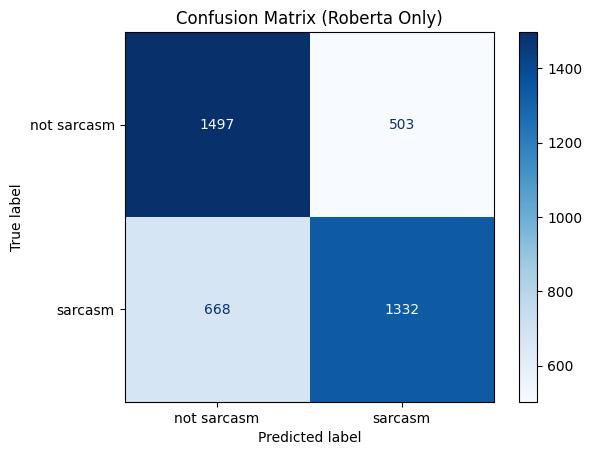

In [31]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


In [32]:
# save the weights
save_path = "/content/drive/MyDrive/SC4021/roberta_sarcasm.pth"

# Save model weights
torch.save(model.state_dict(), save_path)

print(f"Final model weights saved to {save_path}")


Final model weights saved to /content/drive/MyDrive/SC4021/roberta_sarcasm.pth


## bilstm

In [33]:
model_type = "bilstm_only" # Options: "roberta_only", "bilstm_only", "roberta_bilstm"

# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


train_dataset = SarcasmDataset(train_encodings, train_labels)
test_dataset = SarcasmDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


In [34]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6946, Val Loss = 0.6932
Epoch 2: Train Loss = 0.6945, Val Loss = 0.6939
Epoch 3: Train Loss = 0.6947, Val Loss = 0.6964
Epoch 4: Train Loss = 0.6944, Val Loss = 0.6932
Epoch 5: Train Loss = 0.6938, Val Loss = 0.6931
Epoch 6: Train Loss = 0.6940, Val Loss = 0.6932
Epoch 7: Train Loss = 0.6937, Val Loss = 0.6932
Epoch 8: Train Loss = 0.6935, Val Loss = 0.6932
Epoch 9: Train Loss = 0.6936, Val Loss = 0.6932
Epoch 10: Train Loss = 0.6936, Val Loss = 0.6932
Early stopping triggered at epoch 10



Accuracy: 0.5000
Classification Report:
               precision    recall  f1-score   support

 not sarcasm       0.00      0.00      0.00      2000
     sarcasm       0.50      1.00      0.67      2000

    accuracy                           0.50      4000
   macro avg       0.25      0.50      0.33      4000
weighted avg       0.25      0.50      0.33      4000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


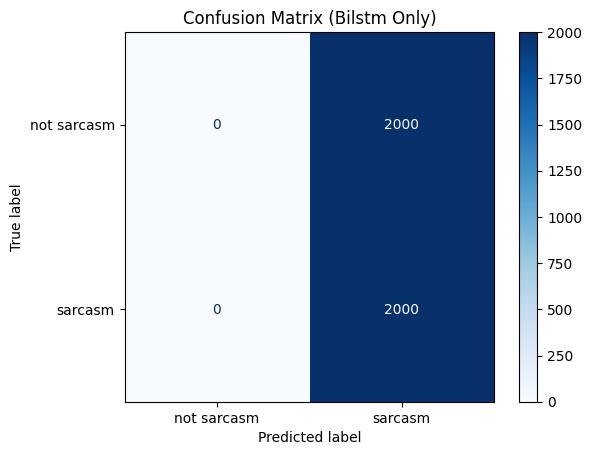

In [35]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


## roberta_bilstm

In [36]:
model_type = "roberta_bilstm" # Options: "roberta_only", "bilstm_only", "roberta_bilstm"

# === Encodings ===
if model_type in ["roberta_only", "roberta_bilstm"]:
    train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)
else:  # bilstm_only
    train_encodings = {"input_ids": [encode_text(t) for t in train_texts]}
    test_encodings = {"input_ids": [encode_text(t) for t in test_texts]}


train_dataset = SarcasmDataset(train_encodings, train_labels)
test_dataset = SarcasmDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# === Model Selection ===
if model_type == "roberta_only":
    model = RobertaOnlyModel().to(device)
elif model_type == "bilstm_only":
    model = BiLSTMOnlyModel(vocab_size).to(device)
elif model_type == "roberta_bilstm":
    model = RobertaBiLSTMModel().to(device)
else:
    raise ValueError(f"Unknown model_type: {model_type}")

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)
criterion = nn.CrossEntropyLoss()


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [37]:
# === Training ===
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if model_type in ["roberta_only", "roberta_bilstm"]:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids, attention_mask)
            else:
                outputs = model(input_ids)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    scheduler.step()


Epoch 1: Train Loss = 0.6293, Val Loss = 0.5796
Epoch 2: Train Loss = 0.5861, Val Loss = 0.5938
Epoch 3: Train Loss = 0.5914, Val Loss = 0.5785
Epoch 4: Train Loss = 0.5588, Val Loss = 0.5704
Epoch 5: Train Loss = 0.5528, Val Loss = 0.5720
Epoch 6: Train Loss = 0.5504, Val Loss = 0.5812
Epoch 7: Train Loss = 0.5450, Val Loss = 0.5705
Epoch 8: Train Loss = 0.5415, Val Loss = 0.5681
Epoch 9: Train Loss = 0.5413, Val Loss = 0.5680
Epoch 10: Train Loss = 0.5399, Val Loss = 0.5686



Accuracy: 0.7105
Classification Report:
               precision    recall  f1-score   support

 not sarcasm       0.69      0.76      0.72      2000
     sarcasm       0.73      0.66      0.70      2000

    accuracy                           0.71      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.71      0.71      4000



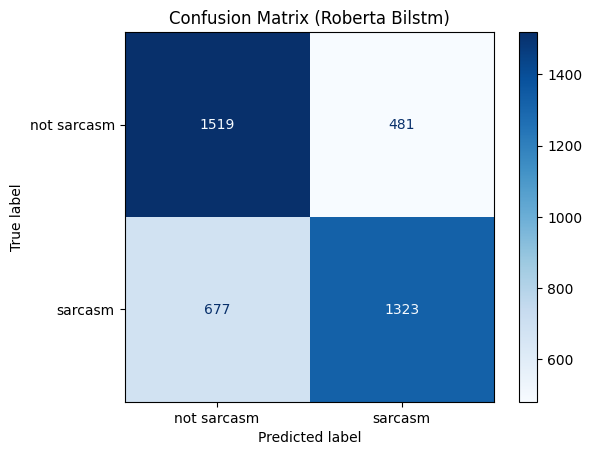

In [38]:
# === Evaluation ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        if model_type in ["roberta_only", "roberta_bilstm"]:
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask)
        else:
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")
print(
    "Classification Report:\n",
    classification_report(all_labels, all_preds, target_names=le.classes_)
)

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=le.classes_, cmap="Blues"
)
plt.title(f"Confusion Matrix ({model_type.replace('_', ' ').title()})")
plt.show()


In [39]:
# save the weights
save_path = "/content/drive/MyDrive/SC4021/roberta_bilstm_sarcasm.pth"

# Save model weights
torch.save(model.state_dict(), save_path)

print(f"Final model weights saved to {save_path}")


Final model weights saved to /content/drive/MyDrive/SC4021/roberta_bilstm_sarcasm.pth
